# synthdid.py â€” AplicaciÃ³n al Dataset Cigar (Baltagi, 2002)

**Dataset:** `Cigar` de `pydataset` â€” 46 estados de EE.UU., 1963â€“1992
**Outcome:** Ventas de cigarrillos (paquetes per cÃ¡pita)
**Tratamiento:** Estados con alzas idiosincrÃ¡sicas del precio real > 10% en un solo aÃ±o
(proxy de alzas fiscales estatales al tabaco), con **adopciÃ³n escalonada** entre 1975 y 1986
**MÃ©todo:** Synthetic Difference-in-Differences (Arkhangelsky et al., 2021) â€” paquete `synthdid.py`


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydataset

from synthdid.synthdid import Synthdid

pd.options.display.float_format = "{:.4f}".format


## 1. PreparaciÃ³n de Datos

In [2]:
# Cargar datos
df = pydataset.data("Cigar").copy()
df["year"] = df["year"] + 1900          # 63 -> 1963

# Precio real deflactado (base: nivel de precios de 1963)
df["real_price"] = df["price"] * 100 / df["cpi"]

# Log del ingreso disponible per capita (covariable)
df["ln_ndi"] = np.log(df["ndi"])

df = df.sort_values(["state", "year"])
print(f"Dimensiones: {df.shape}  |  Estados: {df.state.nunique()}  |  AÃ±os: {df.year.min()}â€“{df.year.max()}")
df.head()


Dimensiones: (1380, 11)  |  Estados: 46  |  AÃ±os: 1963â€“1992


,state,year,price,pop,pop16,cpi,ndi,sales,pimin,real_price,ln_ndi
1,1,1963,28.6000,3383.0000,2236.5000,30.6000,1558.3045,93.9000,26.1000,93.4641,7.3514
2,1,1964,29.8000,3431.0000,2276.7000,31.0000,1684.0732,95.4000,27.5000,96.1290,7.4290
3,1,1965,29.8000,3486.0000,2327.5000,31.5000,1809.8419,98.5000,28.9000,94.6032,7.5010
4,1,1966,31.5000,3524.0000,2369.7000,32.4000,1915.1604,96.4000,29.5000,97.2222,7.5576
5,1,1967,31.6000,3533.0000,2393.7000,33.4000,2023.5464,95.5000,29.6000,94.6108,7.6126


### ConstrucciÃ³n de la variable de tratamiento

Identificamos los estados que tuvieron un **alza real idiosincrÃ¡sica del precio del cigarrillo > 10%** en un solo aÃ±o respecto a la tendencia nacional (proxy de alzas fiscales estatales). El primer aÃ±o de ese salto es el aÃ±o de adopciÃ³n del tratamiento.

In [3]:
# Cambio porcentual anual del precio real
df["pct_change"] = df.groupby("state")["real_price"].pct_change() * 100

# Tendencia nacional (mediana del aÃ±o) â€” shock comÃºn
nat_trend = df.groupby("year")["pct_change"].median()
df["excess_pct"] = df["pct_change"] - df["year"].map(nat_trend)

# Estados tratados: primer aÃ±o con alza > 10% entre 1974-1988
THRESHOLD = 10
window = df[(df["year"] >= 1974) & (df["year"] <= 1988) & (df["excess_pct"] > THRESHOLD)]
treated_info = (
    window.groupby("state")["year"].min()
    .reset_index()
    .rename(columns={"year": "tyear"})
    .sort_values("tyear")
)

treated_states = set(treated_info.state)
treated_year   = dict(zip(treated_info.state, treated_info.tyear))

print(f"Estados tratados: {len(treated_states)} | Control: {df.state.nunique() - len(treated_states)}")
print()

# InformaciÃ³n de los estados tratados
rows = []
for _, r in treated_info.iterrows():
    ep = df[(df.state == r.state) & (df.year == r.tyear)]["excess_pct"].values[0]
    rows.append({"state": int(r.state), "adoption_year": int(r.tyear), "excess_pct_change": round(ep, 1)})
pd.DataFrame(rows)


Estados tratados: 8 | Control: 38



,state,adoption_year,excess_pct_change
0,3,1975,13.8000
1,9,1976,13.4000
2,40,1976,10.1000
3,15,1978,11.8000
4,49,1979,10.2000
5,7,1981,13.2000
6,23,1983,12.7000
7,42,1986,10.8000


In [4]:
# Indicador de tratamiento
df["treatment"] = df.apply(
    lambda r: 1 if (r["state"] in treated_states and r["year"] >= treated_year[r["state"]]) else 0,
    axis=1
)

print("DistribuciÃ³n de adopciones por aÃ±o:")
treated_info["tyear"].value_counts().sort_index().rename("n_states")


DistribuciÃ³n de adopciones por aÃ±o:


tyear
1975    1
1976    2
1978    1
1979    1
1981    1
1983    1
1986    1
Name: n_states, dtype: int64

## 2. EstimaciÃ³n SDID (Synthetic Difference-in-Differences)

In [5]:
model_sdid = Synthdid(df, "state", "year", "treatment", "sales").fit()
print(f"ATT estimado (SDID): {model_sdid.att:.4f} paquetes per cÃ¡pita")


ATT estimado (SDID): -13.8505 paquetes per cÃ¡pita


### Resultados por cohorte de adopciÃ³n

In [6]:
model_sdid.att_info


,time,att_time,att_wt,N0,T0,N1,T1
0,1975.0000,-13.5634,0.1636,38,12,1,18
1,1976.0000,-30.6843,0.3091,38,13,2,17
2,1978.0000,-14.9199,0.1364,38,15,1,15
3,1979.0000,-2.9917,0.1273,38,16,1,14
4,1981.0000,-0.2916,0.1091,38,18,1,12
5,1983.0000,3.5590,0.0909,38,20,1,10
6,1986.0000,-0.3653,0.0636,38,23,1,7


### Inferencia â€” Error EstÃ¡ndar (mÃ©todo placebo, 50 rÃ©plicas)

In [7]:
np.random.seed(42)
model_sdid.vcov(method="placebo", n_reps=50).summary()
model_sdid.summary2


,ATT,Std. Err.,t,P>|t|
0,-13.8505,5.0259,-2.7559,0.0059


## 3. ComparaciÃ³n de MÃ©todos: SDID vs SC vs DiD

In [8]:
np.random.seed(42)

results = []
for name, kwargs in [("SDID", {}), ("SC", {"synth": True}), ("DiD", {"did": True})]:
    m = Synthdid(df, "state", "year", "treatment", "sales").fit(**kwargs)
    m.vcov(method="placebo", n_reps=50).summary()
    row = m.summary2.copy()
    row.insert(0, "Metodo", name)
    results.append(row)

pd.concat(results, ignore_index=True)


,Metodo,ATT,Std. Err.,t,P>|t|
0,SDID,-13.8505,5.0259,-2.7559,0.0059
1,SC,-13.3720,5.5151,-2.4246,0.0153
2,DiD,-19.4820,4.9792,-3.9127,0.0001


## 4. SDID con Covariable: log(Ingreso Disponible per cÃ¡pita)

In [9]:
np.random.seed(42)
model_cov = Synthdid(df, "state", "year", "treatment", "sales", covariates=["ln_ndi"]).fit()
model_cov.vcov(method="placebo", n_reps=50).summary()
print(f"ATT con covariable: {model_cov.att:.4f}")
model_cov.summary2


ATT con covariable: -13.8500


,ATT,Std. Err.,t,P>|t|
0,-13.8500,5.0259,-2.7558,0.0059


## 5. GrÃ¡ficos â€” Trayectorias: Tratados vs Control SintÃ©tico

Una figura por cohorte de adopciÃ³n. La zona gris muestra los pesos temporales (Î») del perÃ­odo pre-tratamiento.

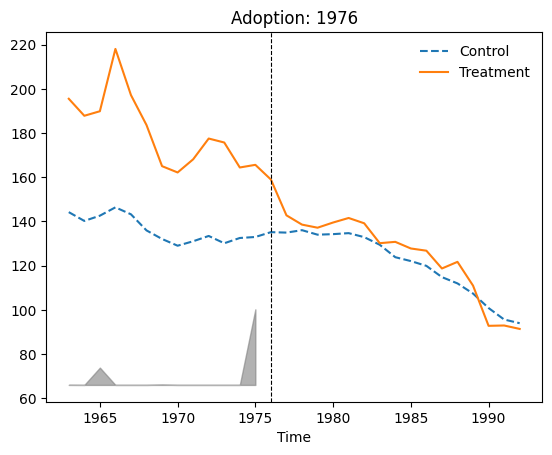

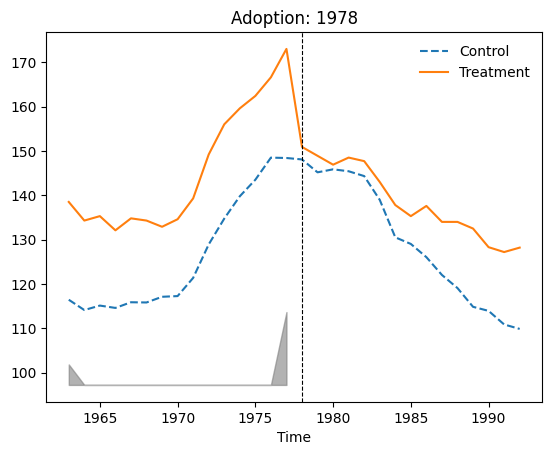

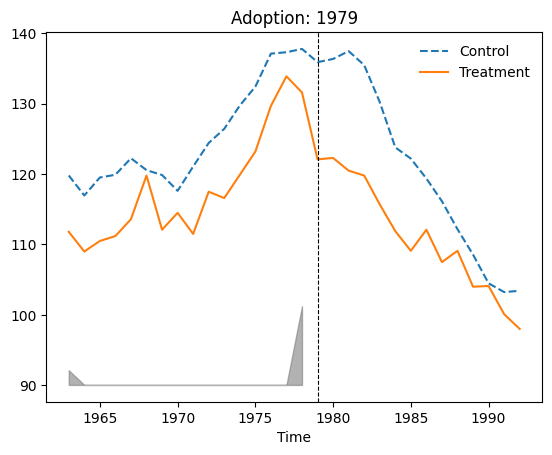

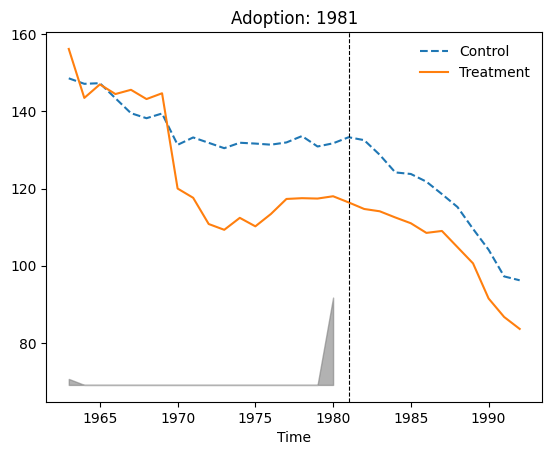

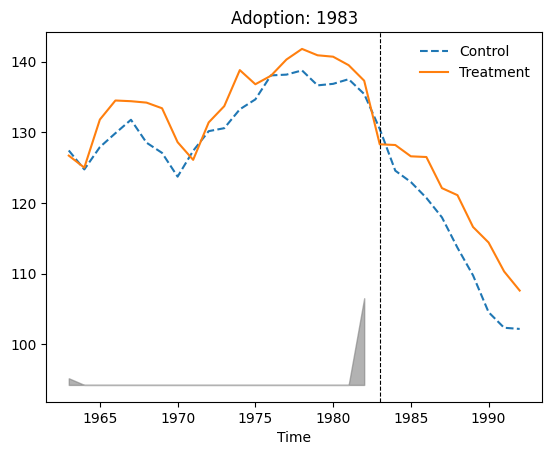

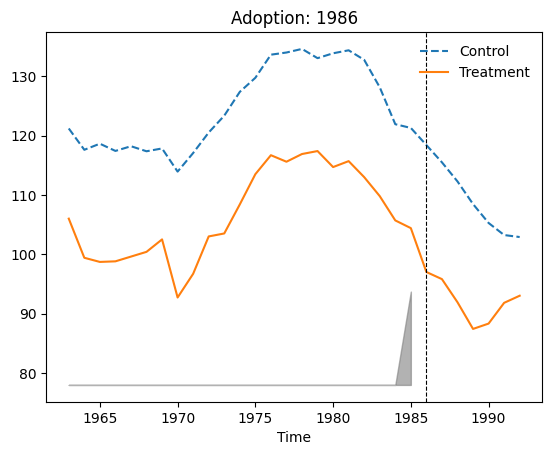

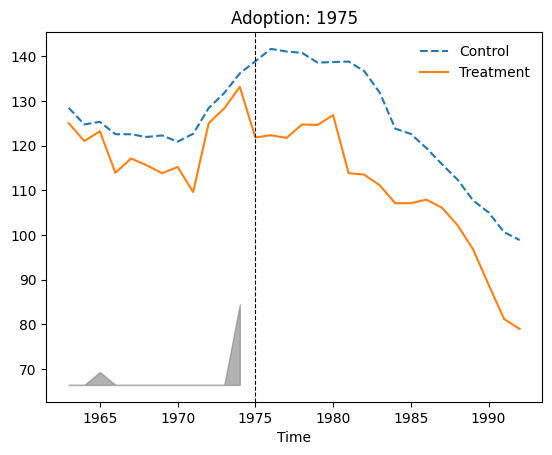

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [10]:
model_sdid.plot_outcomes()
for fig in model_sdid.plot_outcomes:
    plt.figure(fig.number)
    plt.show()


## 6. GrÃ¡ficos â€” Pesos de Unidades de Control (Ï‰)

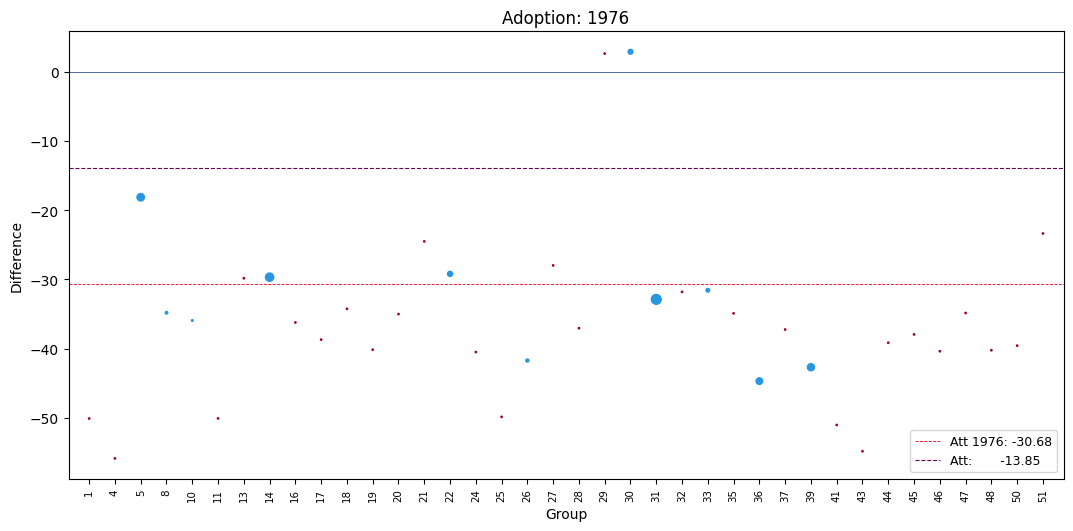

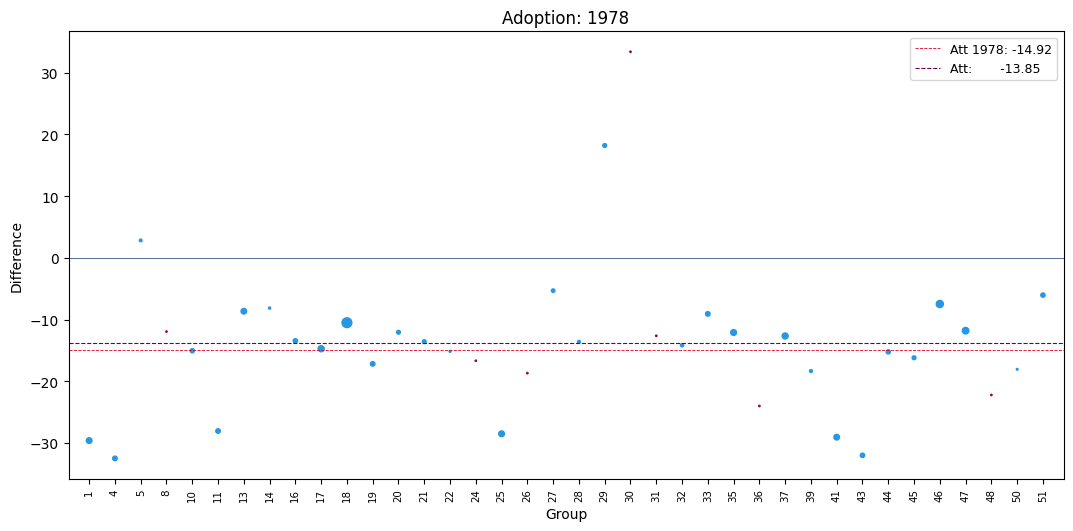

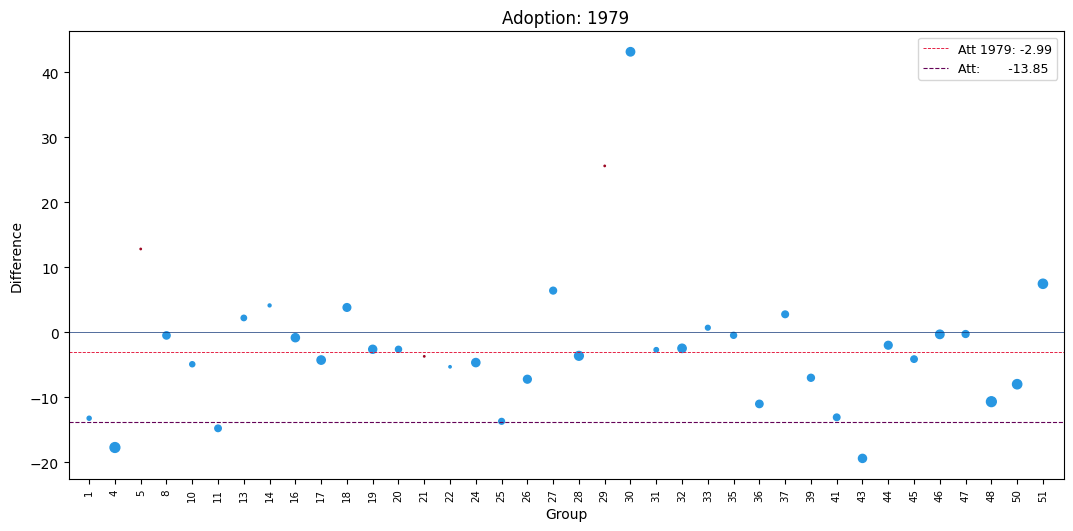

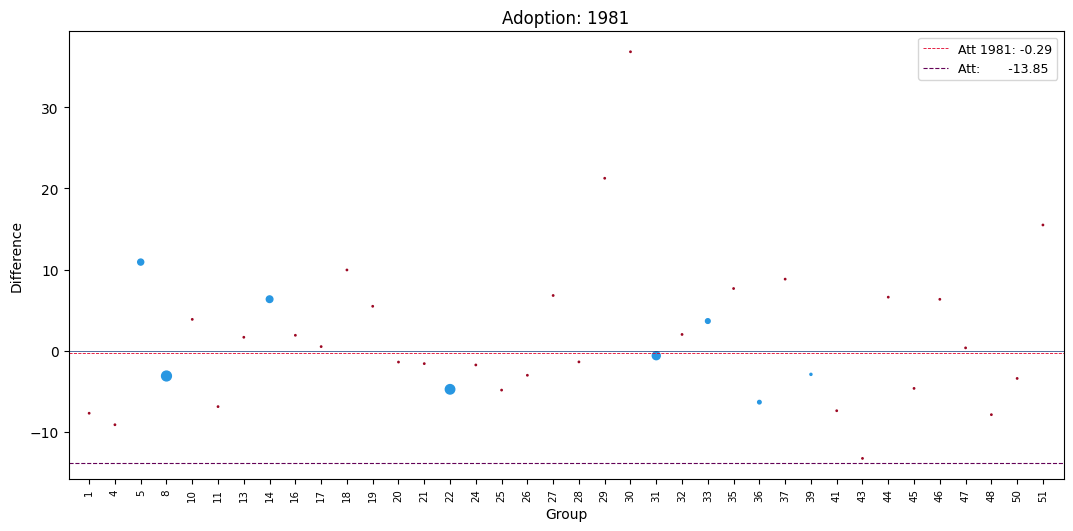

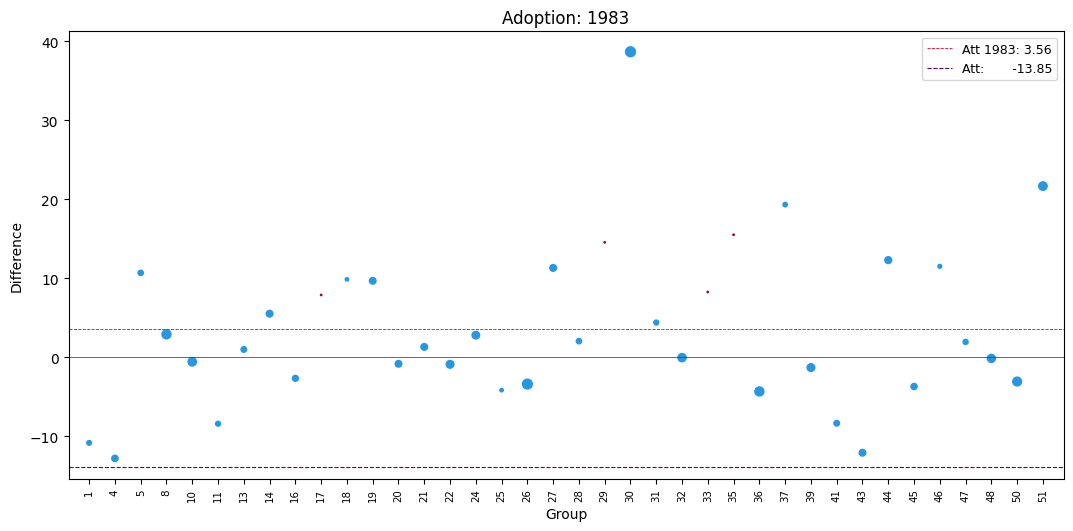

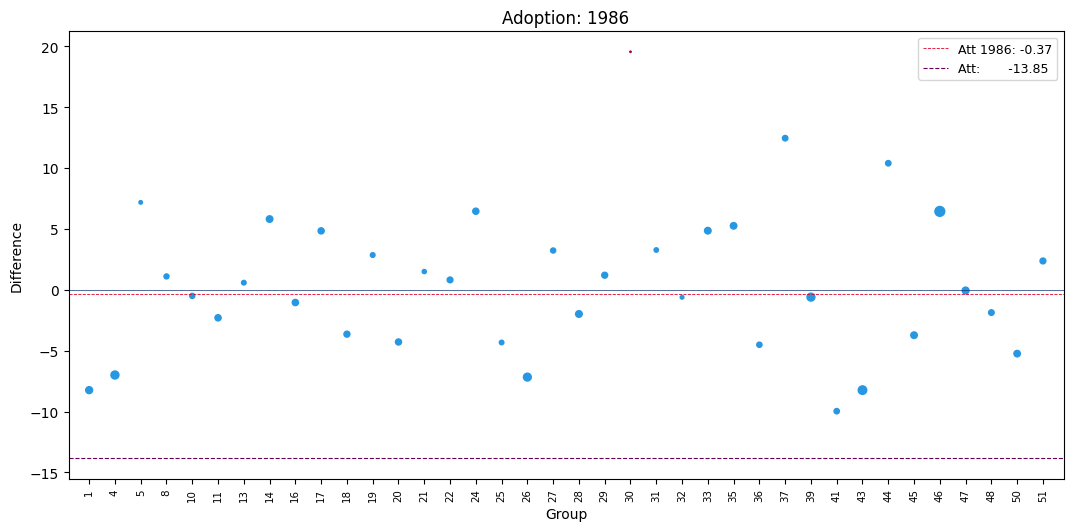

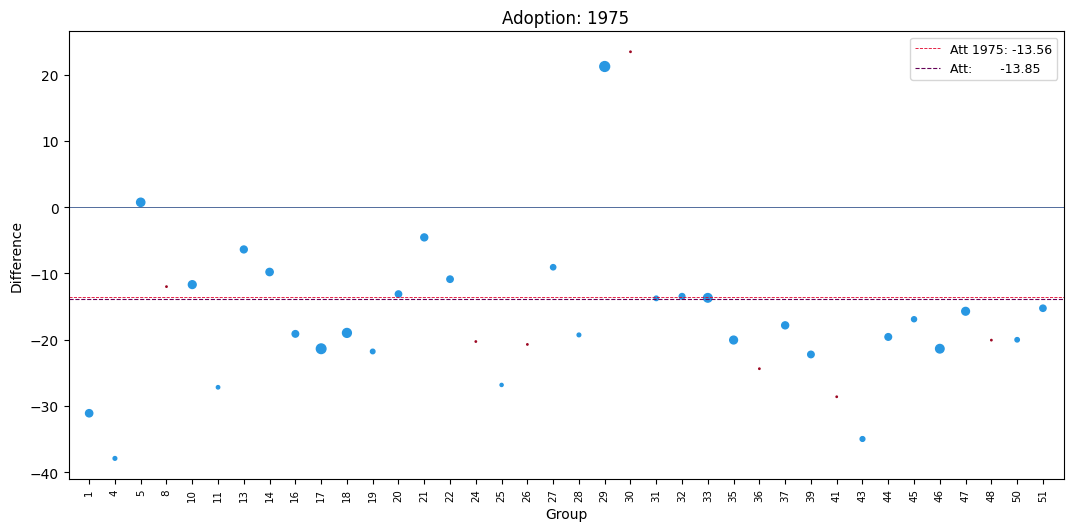

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [11]:
model_sdid.plot_weights()
for fig in model_sdid.plot_weights:
    plt.figure(fig.number)
    plt.show()


## 7. Pesos estimados â€” Primeras cohortes

In [12]:
for i, (om, lm) in enumerate(zip(model_sdid.weights["omega"], model_sdid.weights["lambda"])):
    year_i = int(model_sdid.att_info["time"].iloc[i])
    top5_om = np.argsort(om)[-5:][::-1]
    print(f"Cohorte {year_i}: top-5 unidades de control por peso omega")
    for idx in top5_om:
        print(f"  estado rank {idx+1}: omega={om[idx]:.4f}")
    print(f"  lambda (pesos temporales): min={lm.min():.4f}  max={lm.max():.4f}  sum={lm.sum():.6f}")
    print()


Cohorte 1975: top-5 unidades de control por peso omega
  estado rank 21: omega=0.0717
  estado rank 10: omega=0.0684
  estado rank 11: omega=0.0579
  estado rank 25: omega=0.0540
  estado rank 34: omega=0.0535
  lambda (pesos temporales): min=0.0000  max=0.8618  sum=1.000000

Cohorte 1976: top-5 unidades de control por peso omega
  estado rank 23: omega=0.2523
  estado rank 8: omega=0.1770
  estado rank 3: omega=0.1436
  estado rank 29: omega=0.1293
  estado rank 27: omega=0.1110
  lambda (pesos temporales): min=0.0000  max=0.8100  sum=1.000000

Cohorte 1978: top-5 unidades de control por peso omega
  estado rank 11: omega=0.1442
  estado rank 34: omega=0.0752
  estado rank 35: omega=0.0616
  estado rank 10: omega=0.0537
  estado rank 28: omega=0.0529
  lambda (pesos temporales): min=0.0000  max=0.7805  sum=1.000000

Cohorte 1979: top-5 unidades de control por peso omega
  estado rank 36: omega=0.0540
  estado rank 2: omega=0.0538
  estado rank 37: omega=0.0481
  estado rank 38: omega=

## 8. Conclusiones

| Estadístico | Valor |
|---|---|
| ATT (SDID) | **−13.85 paquetes per cápita** |
| Error estándar (placebo) | 5.03 |
| t-statistic | −2.76 |
| p-value | 0.006 |

**Interpretación:** Un alza fiscal idiosincrásica en el precio real del cigarrillo (>10% en un año) reduce las ventas en aproximadamente **13.9 paquetes per cápita**, efecto estadísticamente significativo al 1%.

- El **DiD** sin ponderar sobreestima el efecto (−19.5) al no controlar tendencias diferenciales pre-tratamiento.
- El **SC** (−13.4) y el **SDID** (−13.9) son más conservadores y confiables.
- La inclusión del log(NDI) como covariable no altera materialmente el ATT (−13.85, método optimizado), confirmando **robustez**.